# Regresyon Analizi | 25 Kasım 2025

## Örnek 1

In [41]:
set.seed(123)

In [42]:
# Veriyi oluşturma
calisma_saat <- c(1:10)
sinav_puani <- c(52, 55, 59, 63, 66, 70, 72, 75, 78, 82)
veri <- data.frame(calisma_saat, sinav_puani)
veri

calisma_saat,sinav_puani
<int>,<dbl>
1,52
2,55
3,59
4,63
5,66
6,70
7,72
8,75
9,78


In [43]:
# Doğrusal regresyon modelini oluşturma
# lm(): linear model fonksiyonu
# Sınav puanı bağımlı değişken, çalışma saati ise bağımsız değişkendir.
# 
# sinav_puani ~ calisma_saat ifadesi, sınav puanının çalışma saatine bağlı olduğunu belirtir.
model <- lm(sinav_puani ~ calisma_saat, data = veri)
summary(model)


Call:
lm(formula = sinav_puani ~ calisma_saat, data = veri)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.70303 -0.41667 -0.05758  0.33636  1.15758 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  49.13333    0.44574  110.23 5.13e-14 ***
calisma_saat  3.28485    0.07184   45.73 5.78e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6525 on 8 degrees of freedom
Multiple R-squared:  0.9962,	Adjusted R-squared:  0.9957 
F-statistic:  2091 on 1 and 8 DF,  p-value: 5.78e-11


Sınav puanı = 49.13 + 3.28 * Çalışma saati\
B0 Standart hatası: 0.44574\
B1 Standart hatası: 0.07184

P value değeri: `Pr(>|t|)`
Çıktıdaki yıldızlar '***' ise p-değerinin çok düşük olduğunu ve modelin istatistiksel olarak çok çok anlamlı olduğunu gösterir.

---

Eklediğiniz her değer R kare değerini artırır, bu nedenle modelin başarısını değerlendirmek için sadece R kare değerine bakmak yanıltıcı olabilir. Bunun yerine, düzeltilmiş R kare değerine bakmak daha iyidir.

### Hipotez

H0: B1 = 0 (Bağımsız değişkenin bağımlı değişken üzerinde etkisi yoktur. **Model anlamsızdır**.)\
H1: B1 ≠ 0 (Bağımsız değişkenin bağımlı değişken üzerinde etkisi vardır. **Model anlamlıdır**.)

Çıktı:

```R
F-statistic:  2091 on 1 and 8 DF,  p-value: 5.78e-11
```

Elde edilen p-value değeri 0.05'ten çok daha küçük olduğu için H0 hipotezi reddedilir ve modelin anlamlı olduğu sonucuna varılır.

In [44]:
# Katsayılar
coef(model)

(Intercept) calisma_saat 
   49.133333     3.284848

### Tahmin

In [45]:
# 6 saat çalışma durumunda sınav puanını tahmin etme
predict(model, data.frame(calisma_saat = 6))

1 
68.84242

### Grafik

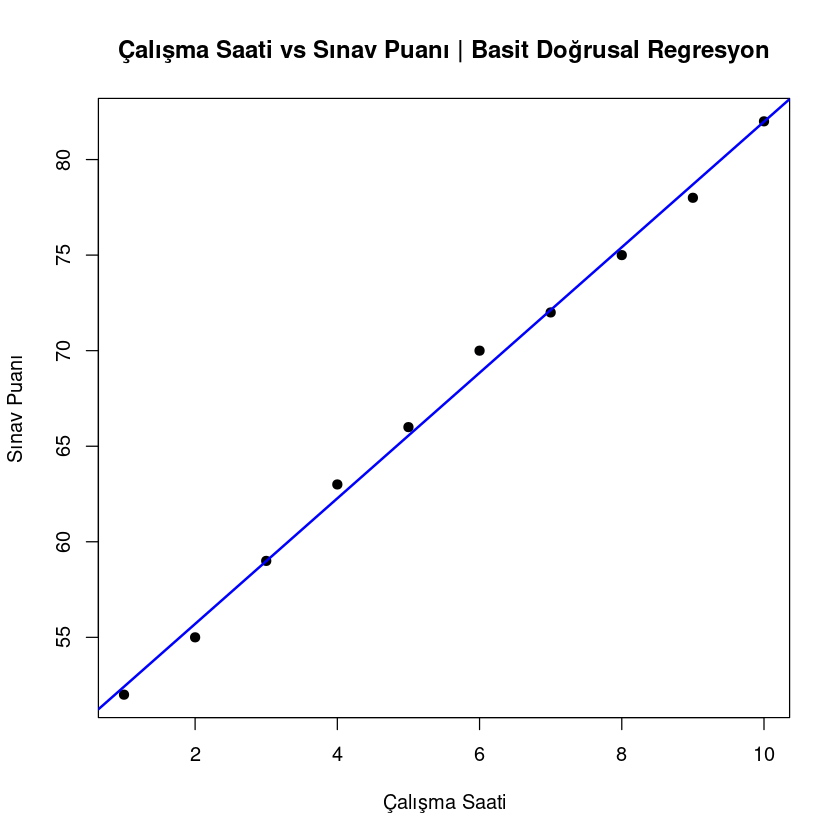

In [46]:
# Saçılım grafiği
plot(
    veri$calisma_saat,
    veri$sinav_puani,
    main = "Çalışma Saati vs Sınav Puanı | Basit Doğrusal Regresyon",
    xlab = "Çalışma Saati",
    ylab = "Sınav Puanı",
    pch = 19,
)
# Grafik üzerine regresyon doğrusunu ekleme
abline(model, col = "blue", lwd = 2)

## Örnek 2

In [47]:
set.seed(42)

In [48]:
ay <- 1:12
reklam <- c(5, 7, 6, 9, 12, 15, 14, 16, 18, 20, 22, 25) # Bin tl
satis <- c(55, 58, 57, 65, 72, 78, 80, 83, 88, 92, 95, 102)

veri2 <- data.frame(ay, reklam, satis)
veri2
summary(veri2)

ay,reklam,satis
<int>,<dbl>,<dbl>
1,5,55
2,7,58
3,6,57
4,9,65
5,12,72
6,15,78
7,14,80
8,16,83
9,18,88


       ay            reklam          satis       
 Min.   : 1.00   Min.   : 5.00   Min.   : 55.00  
 1st Qu.: 3.75   1st Qu.: 8.50   1st Qu.: 63.25  
 Median : 6.50   Median :14.50   Median : 79.00  
 Mean   : 6.50   Mean   :14.08   Mean   : 77.08  
 3rd Qu.: 9.25   3rd Qu.:18.50   3rd Qu.: 89.00  
 Max.   :12.00   Max.   :25.00   Max.   :102.00  

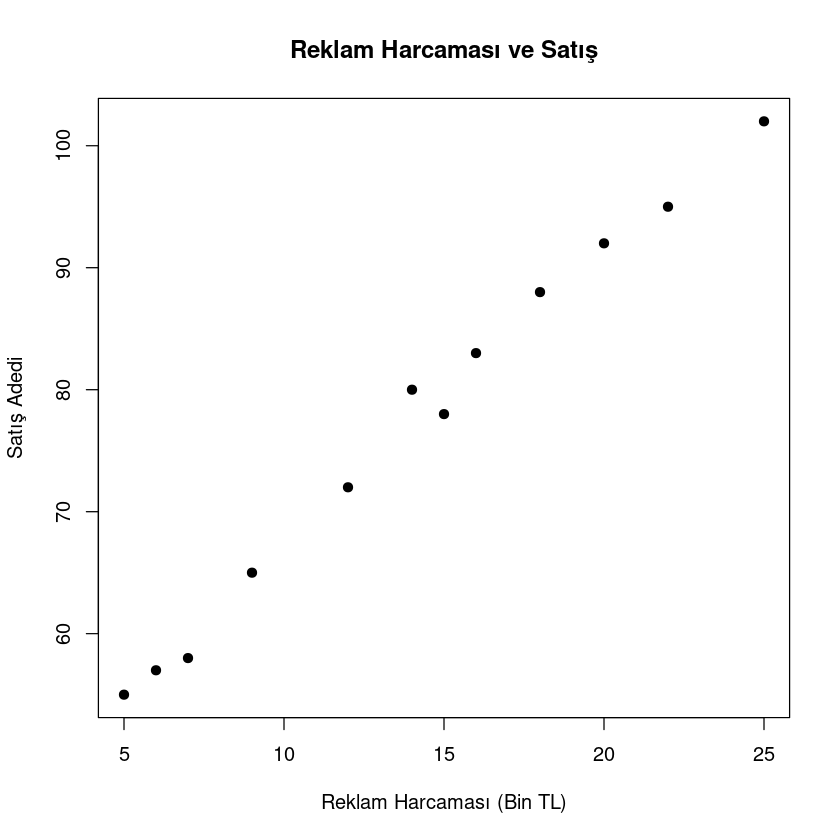

In [49]:
plot(
    veri2$reklam,
    veri2$satis,
    main = "Reklam Harcaması ve Satış",
    xlab = "Reklam Harcaması (Bin TL)",
    ylab = "Satış Adedi",
    pch = 19,
)

In [50]:
satis_reklam_modeli <- lm(satis ~ reklam, data = veri2)
summary(satis_reklam_modeli)


Call:
lm(formula = satis ~ reklam, data = veri2)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.91396 -1.28079 -0.04983  0.74910  3.11866 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  42.9466     1.0917   39.34 2.69e-12 ***
reklam        2.4239     0.0709   34.19 1.09e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.529 on 10 degrees of freedom
Multiple R-squared:  0.9915,	Adjusted R-squared:  0.9907 
F-statistic:  1169 on 1 and 10 DF,  p-value: 1.085e-11


Satış adedi = 42.9466 + 2.4339 * Reklam

Reklamlardaki 1 birimlik artış, satışlarda ortalama 2.4339 birimlik bir artışa neden olur.\
Hiç reklam yapılmadığında (reklam = 0), satış adedi ortalama olarak 42.9466 birimdir.

B0 Standart hatası: 1.0917\
B1 Standart hatası: 0.0709

### Tahmin

In [51]:
# 33 birimlik reklam harcaması durumunda satış adedini tahmin etme
predict(satis_reklam_modeli, data.frame(reklam = 33))

1 
122.9357

### Grafik

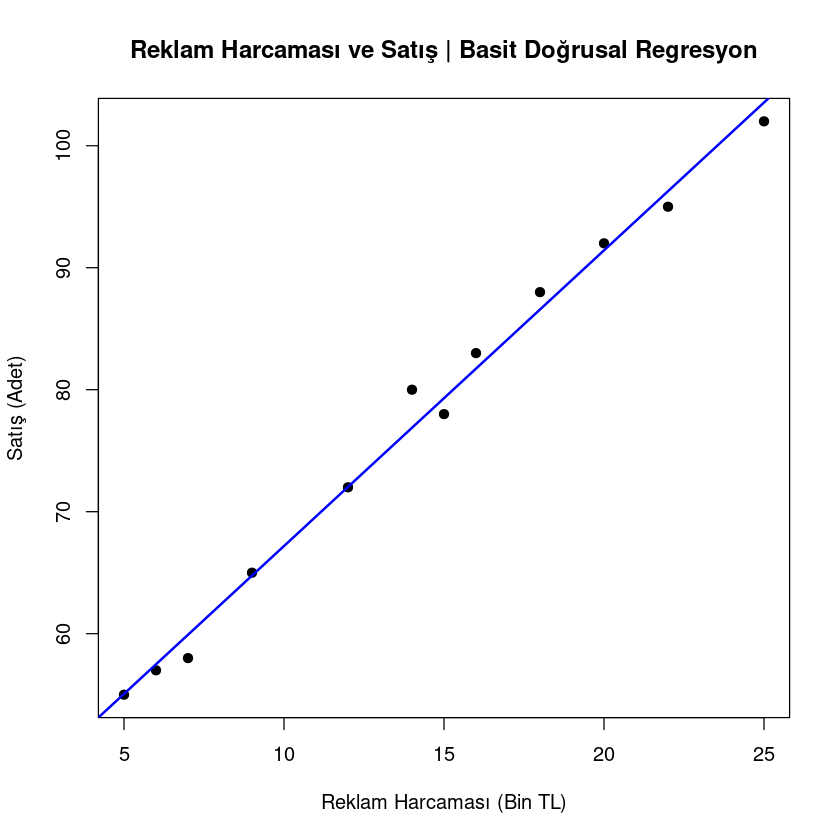

In [52]:
plot(
    veri2$reklam,
    veri2$satis,
    main = "Reklam Harcaması ve Satış | Basit Doğrusal Regresyon",
    xlab = "Reklam Harcaması (Bin TL)",
    ylab = "Satış (Adet)",
    pch = 19,
)
abline(satis_reklam_modeli, col = "blue", lwd = 2)

### Grafik - Artıklar

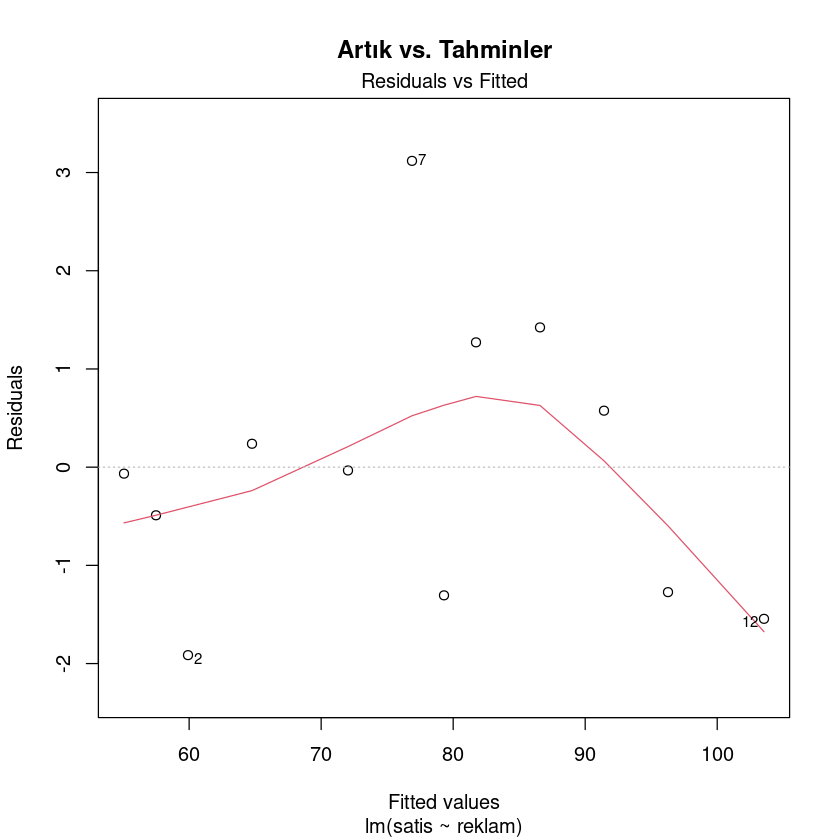

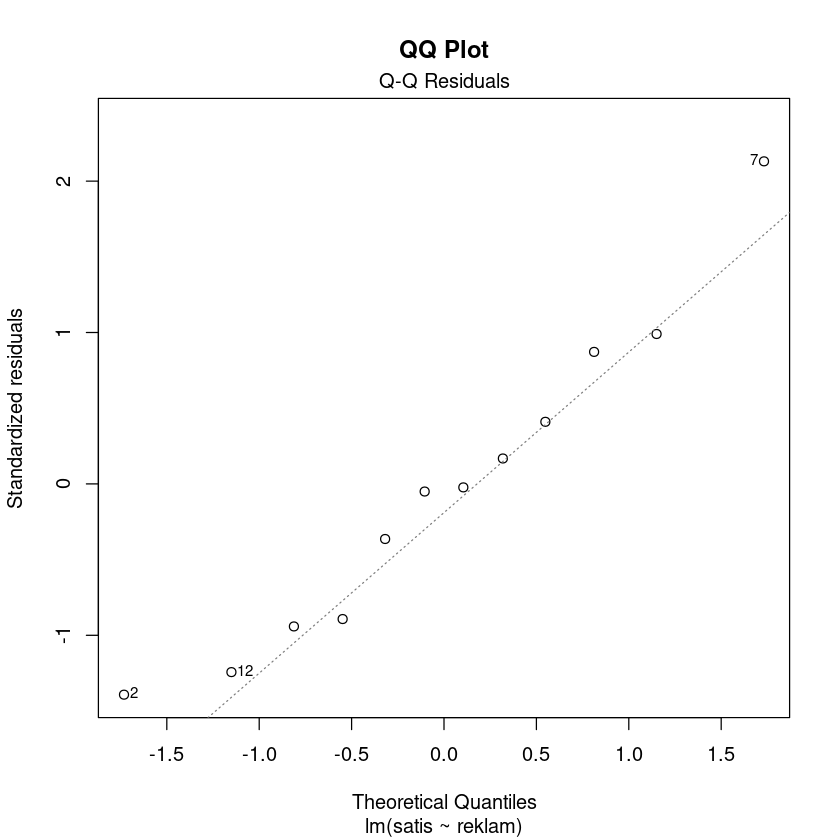

In [53]:
plot(satis_reklam_modeli, which = 1, main="Artık vs. Tahminler")
plot(satis_reklam_modeli, which = 2, main="QQ Plot")

## Diyabet Verisi

In [54]:
library(readr)
diabetes <- read_csv("./diabetes2.csv")

BloodPressure <- diabetes$BloodPressure
Glucose <- diabetes$Glucose

Rows: 768 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, D...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [55]:
summary(diabetes)

  Pregnancies        Glucose      BloodPressure    SkinThickness  
 Min.   : 0.000   Min.   :  0.0   Min.   :  0.00   Min.   : 0.00  
 1st Qu.: 1.000   1st Qu.: 99.0   1st Qu.: 62.00   1st Qu.: 0.00  
 Median : 3.000   Median :117.0   Median : 72.00   Median :23.00  
 Mean   : 3.845   Mean   :120.9   Mean   : 69.11   Mean   :20.54  
 3rd Qu.: 6.000   3rd Qu.:140.2   3rd Qu.: 80.00   3rd Qu.:32.00  
 Max.   :17.000   Max.   :199.0   Max.   :122.00   Max.   :99.00  
    Insulin           BMI        DiabetesPedigreeFunction      Age       
 Min.   :  0.0   Min.   : 0.00   Min.   :0.0780           Min.   :21.00  
 1st Qu.:  0.0   1st Qu.:27.30   1st Qu.:0.2437           1st Qu.:24.00  
 Median : 30.5   Median :32.00   Median :0.3725           Median :29.00  
 Mean   : 79.8   Mean   :31.99   Mean   :0.4719           Mean   :33.24  
 3rd Qu.:127.2   3rd Qu.:36.60   3rd Qu.:0.6262           3rd Qu.:41.00  
 Max.   :846.0   Max.   :67.10   Max.   :2.4200           Max.   :81.00  
    Outcome  

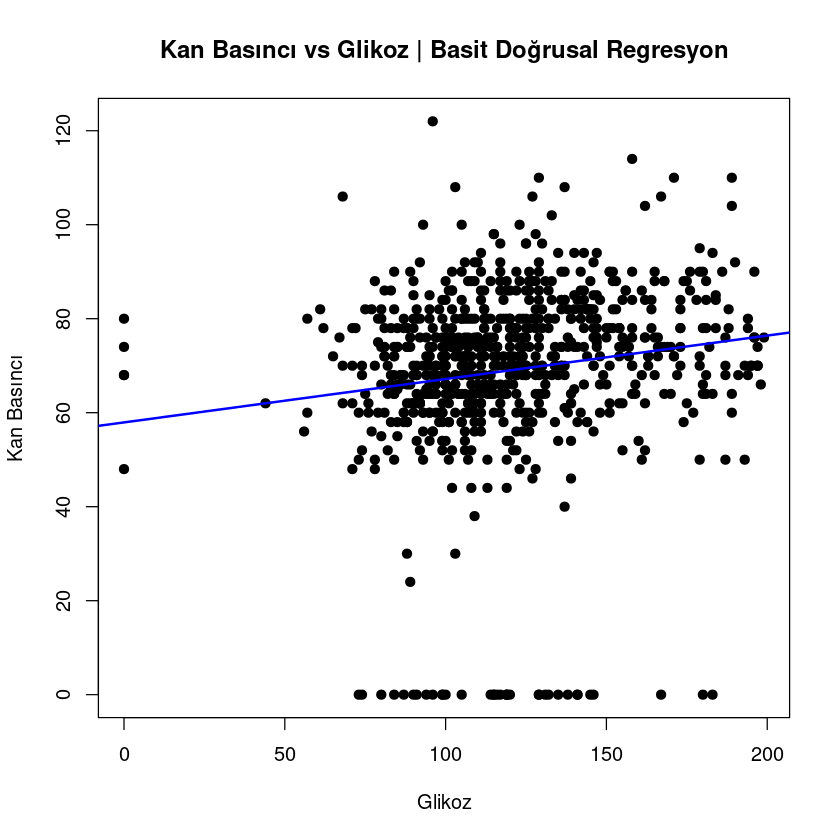

In [59]:
plot(
    Glucose,
    BloodPressure,
    main="Kan Basıncı vs Glikoz | Basit Doğrusal Regresyon",
    xlab="Glikoz",
    ylab="Kan Basıncı",
    pch=19
)
abline(glikoz_kan_basinci_modeli, col="blue", lwd=2)

(aykırı değeri modelden çıkartma işlemleri tek tek yapılır ve model yeniden oluşturulur)

In [57]:
glikoz_kan_basinci_modeli <- lm(BloodPressure ~ Glucose, data=diabetes)
summary(glikoz_kan_basinci_modeli)


Call:
lm(formula = BloodPressure ~ Glucose, data = diabetes)

Residuals:
    Min      1Q  Median      3Q     Max 
-74.843  -5.914   2.333  10.676  55.194 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 57.93775    2.70316  21.433  < 2e-16 ***
Glucose      0.09238    0.02162   4.273 2.17e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 19.14 on 766 degrees of freedom
Multiple R-squared:  0.02328,	Adjusted R-squared:  0.02201 
F-statistic: 18.26 on 1 and 766 DF,  p-value: 2.17e-05


### Yorum

...